In [9]:
pip install torch torchvision scipy numpy scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


All imports successful!
  Indian_pines_corrected.mat already exists, skipping.
  Indian_pines_gt.mat already exists, skipping.
  Salinas_corrected.mat done!
  Salinas_gt.mat done!
  PaviaU.mat already exists, skipping.
  PaviaU_gt.mat already exists, skipping.
  LK download failed (will skip LK): HTTP Error 403: Forbidden
  LK download failed (will skip LK): HTTP Error 403: Forbidden

All available datasets downloaded!
Data functions defined!
Model defined!

  Training on: IP  |  Device: cuda
  Bands: 200 | Classes: 16
  Train: 307 | Test: 9942
  Epoch [ 50/300]  Loss: 0.2551  OA: 91.69%
    --> Best saved! OA: 91.69%
  Epoch [100/300]  Loss: 0.0987  OA: 93.83%
    --> Best saved! OA: 93.83%
  Epoch [150/300]  Loss: 0.0637  OA: 93.87%
    --> Best saved! OA: 93.87%
  Epoch [200/300]  Loss: 0.0474  OA: 93.87%
  Epoch [250/300]  Loss: 0.0450  OA: 94.28%
    --> Best saved! OA: 94.28%
  Epoch [300/300]  Loss: 0.0421  OA: 94.23%

  FINAL RESULTS [IP]
  OA    : 94.28%
  AA    : 84.32%
  Kap

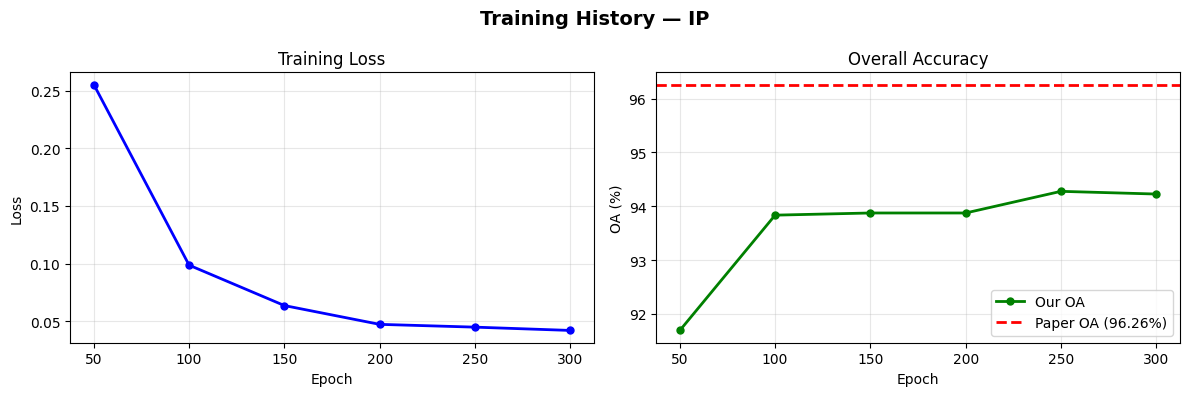

Saved: history_IP.png


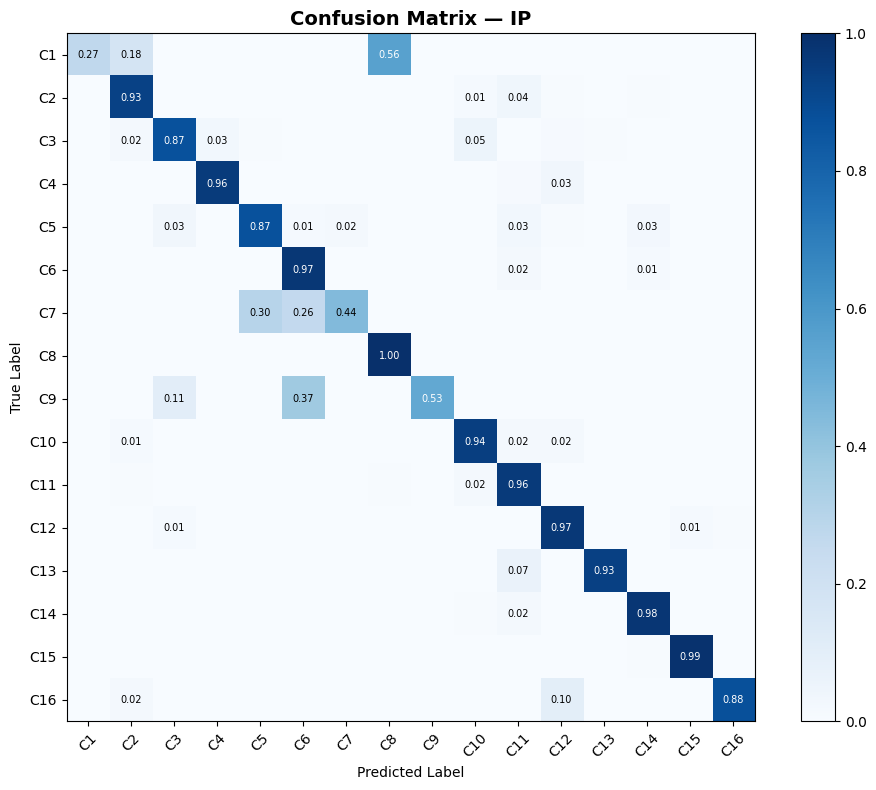

Saved: cm_IP.png

  Training on: SA  |  Device: cuda
  Bands: 204 | Classes: 16
  Train: 1623 | Test: 52506
  Epoch [ 50/300]  Loss: 0.0960  OA: 99.11%
    --> Best saved! OA: 99.11%
  Epoch [100/300]  Loss: 0.0393  OA: 99.08%
  Epoch [150/300]  Loss: 0.0111  OA: 99.48%
    --> Best saved! OA: 99.48%
  Epoch [200/300]  Loss: 0.0161  OA: 99.61%
    --> Best saved! OA: 99.61%
  Epoch [250/300]  Loss: 0.0046  OA: 99.76%
    --> Best saved! OA: 99.76%
  Epoch [300/300]  Loss: 0.0032  OA: 99.73%

  FINAL RESULTS [SA]
  OA    : 99.76%
  AA    : 99.76%
  Kappa : 99.73


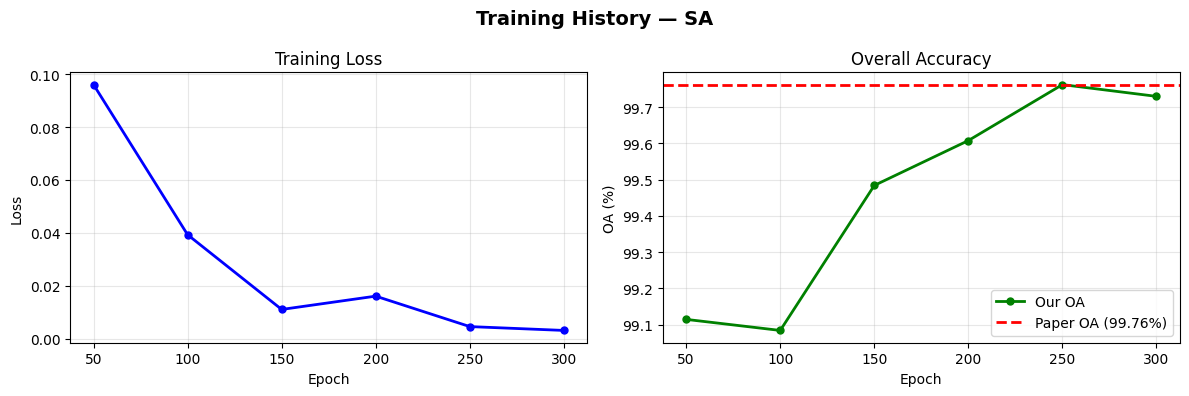

Saved: history_SA.png


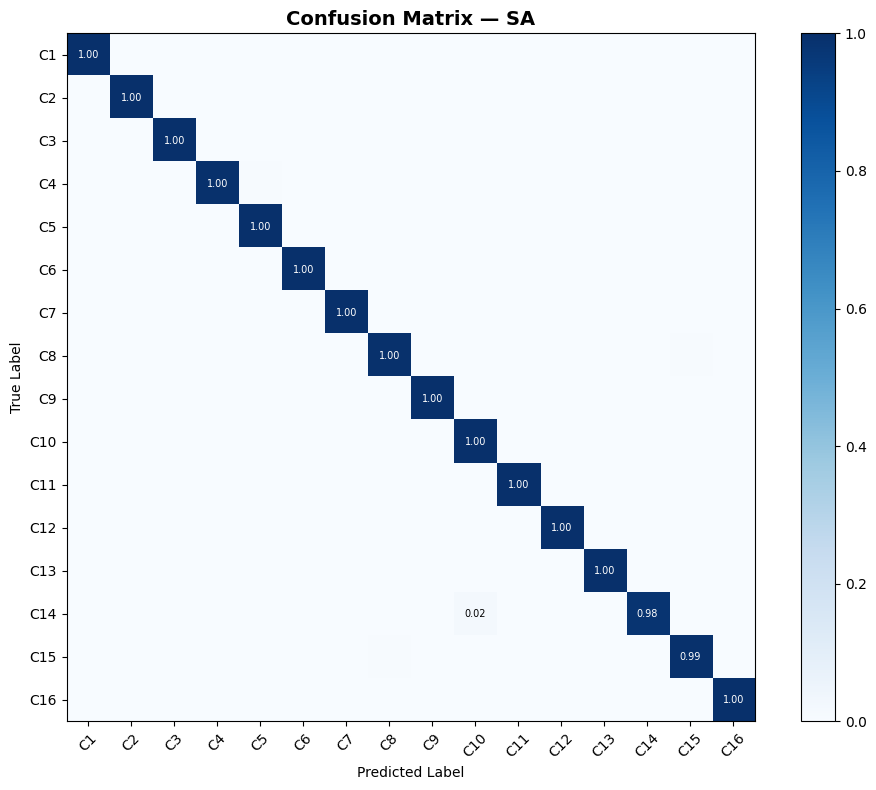

Saved: cm_SA.png

  Training on: PU  |  Device: cuda
  Bands: 103 | Classes: 9
  Train: 1283 | Test: 41493
  Epoch [ 50/300]  Loss: 0.1131  OA: 97.58%
    --> Best saved! OA: 97.58%
  Epoch [100/300]  Loss: 0.0999  OA: 98.90%
    --> Best saved! OA: 98.90%
  Epoch [150/300]  Loss: 0.2152  OA: 95.61%
  Epoch [200/300]  Loss: 0.0554  OA: 99.01%
    --> Best saved! OA: 99.01%
  Epoch [250/300]  Loss: 0.0151  OA: 99.03%
    --> Best saved! OA: 99.03%
  Epoch [300/300]  Loss: 0.0137  OA: 99.09%
    --> Best saved! OA: 99.09%

  FINAL RESULTS [PU]
  OA    : 99.09%
  AA    : 98.12%
  Kappa : 98.80


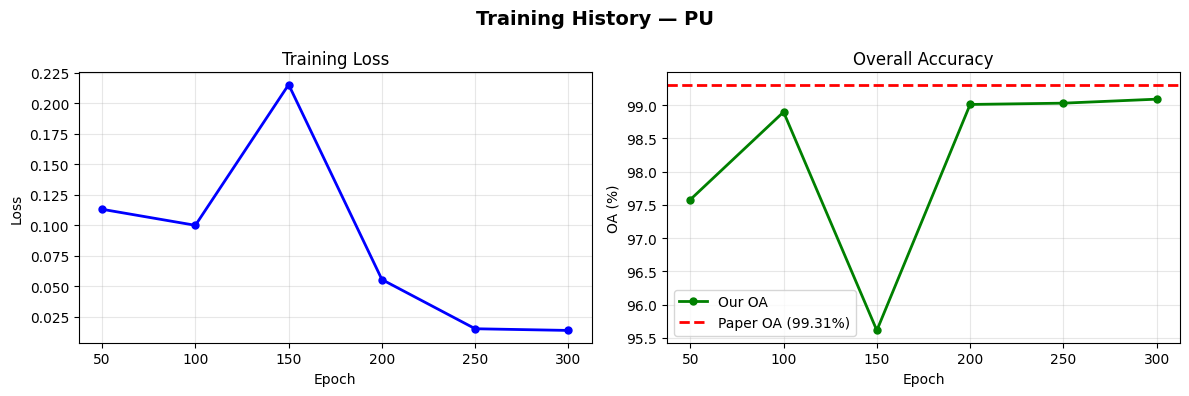

Saved: history_PU.png


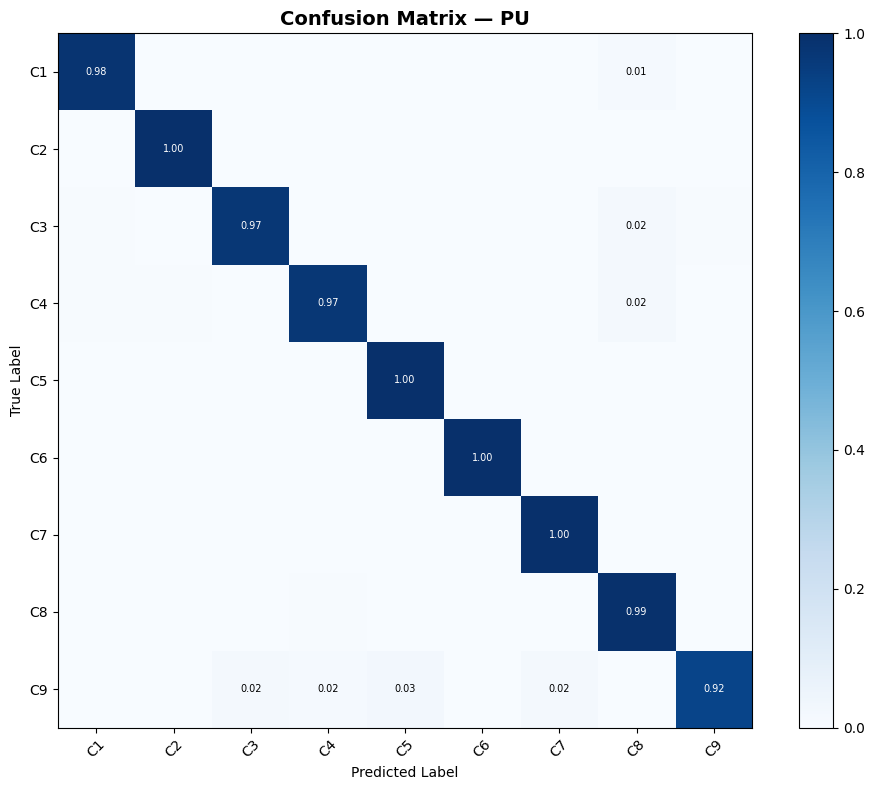

Saved: cm_PU.png

Skipping LK dataset (download failed).
You can manually upload WHU_Hi_LongKou.mat to the data/ folder.

Generating final comparison plots...


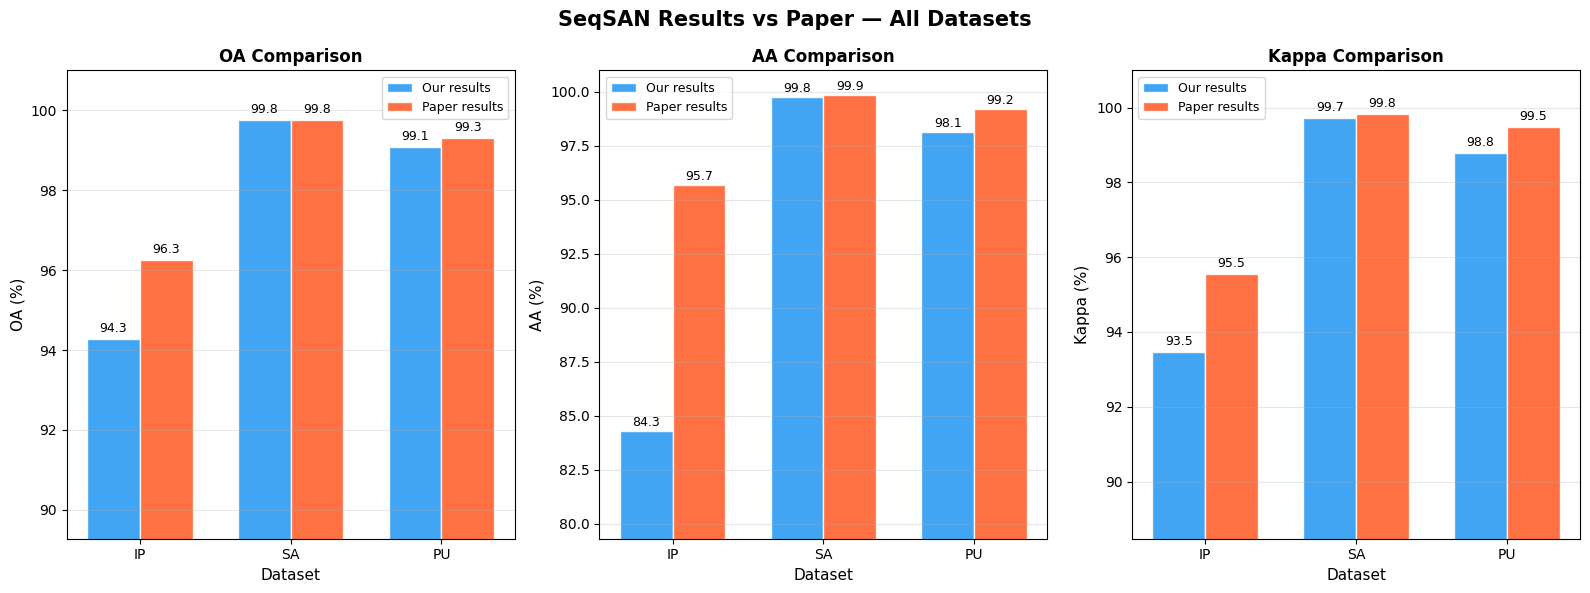

Saved: comparison_all_datasets.png


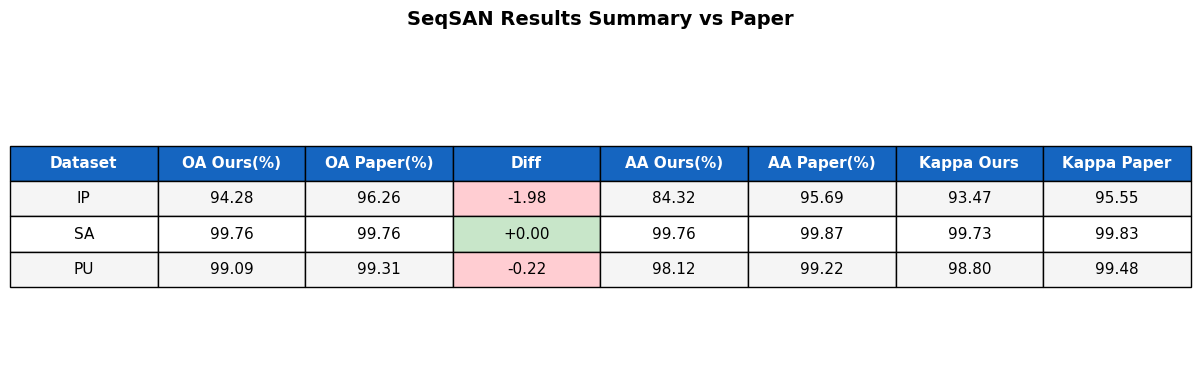

Saved: summary_table.png


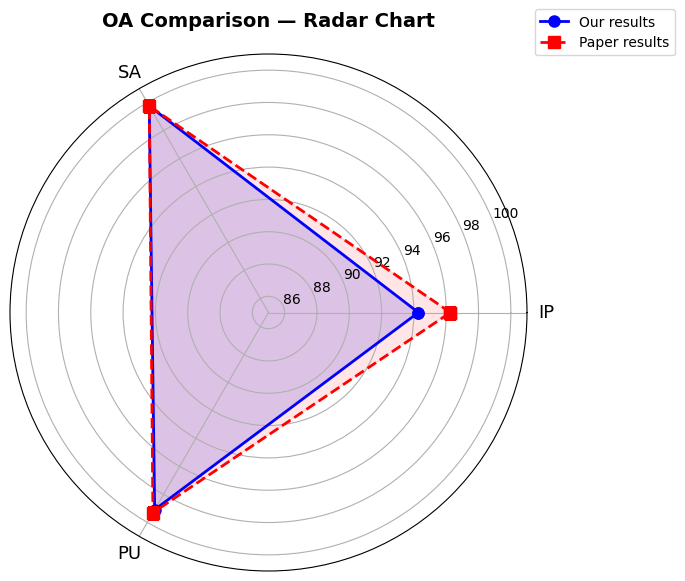

Saved: radar_comparison.png

  FINAL SUMMARY
Dataset       OA Ours   OA Paper    AA Ours      Kappa
-------------------------------------------------------
IP             94.28%     96.26%     84.32%     93.47
SA             99.76%     99.76%     99.76%     99.73
PU             99.09%     99.31%     98.12%     98.80

Done! All plots saved as PNG files.


In [5]:
# ============================================================
# SeqSAN - COMPLETE CODE ALL 4 DATASETS + PLOTS
# ============================================================

# --- IMPORTS ---
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import scipy.io as sio
import urllib.request
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import cohen_kappa_score, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

# ============================================================
# STEP 1: DOWNLOAD ALL 4 DATASETS
# ============================================================

os.makedirs('data', exist_ok=True)

urls = {
    'Indian_pines_corrected.mat' : 'http://www.ehu.eus/ccwintco/uploads/6/67/Indian_pines_corrected.mat',
    'Indian_pines_gt.mat'        : 'http://www.ehu.eus/ccwintco/uploads/c/c4/Indian_pines_gt.mat',
    'Salinas_corrected.mat'      : 'http://www.ehu.eus/ccwintco/uploads/a/a3/Salinas_corrected.mat',
    'Salinas_gt.mat'             : 'http://www.ehu.eus/ccwintco/uploads/f/fa/Salinas_gt.mat',
    'PaviaU.mat'                 : 'http://www.ehu.eus/ccwintco/uploads/e/ee/PaviaU.mat',
    'PaviaU_gt.mat'              : 'http://www.ehu.eus/ccwintco/uploads/5/50/PaviaU_gt.mat',
}

for filename, url in urls.items():
    path = f'data/{filename}'
    if not os.path.exists(path):
        print(f"Downloading {filename}...")
        try:
            urllib.request.urlretrieve(url, path)
            print(f"  {filename} done!")
        except Exception as e:
            print(f"  Failed: {e}")
    else:
        print(f"  {filename} already exists, skipping.")

# LK dataset - download from alternate source
LK_files = {
    'WHU_Hi_LongKou.mat'    : 'http://rsidea.whu.edu.cn/resource/WHU-Hi/WHU_Hi_LongKou.mat',
    'WHU_Hi_LongKou_gt.mat' : 'http://rsidea.whu.edu.cn/resource/WHU-Hi/WHU_Hi_LongKou_gt.mat',
}
lk_available = True
for filename, url in LK_files.items():
    path = f'data/{filename}'
    if not os.path.exists(path):
        print(f"Downloading {filename}...")
        try:
            urllib.request.urlretrieve(url, path)
            print(f"  {filename} done!")
        except Exception as e:
            print(f"  LK download failed (will skip LK): {e}")
            lk_available = False
    else:
        print(f"  {filename} already exists.")

print("\nAll available datasets downloaded!")

# ============================================================
# STEP 2: DATA LOADING & PREPROCESSING
# ============================================================

def load_dataset(name):
    if name == 'IP':
        data   = sio.loadmat('data/Indian_pines_corrected.mat')['indian_pines_corrected']
        labels = sio.loadmat('data/Indian_pines_gt.mat')['indian_pines_gt']
    elif name == 'SA':
        data   = sio.loadmat('data/Salinas_corrected.mat')['salinas_corrected']
        labels = sio.loadmat('data/Salinas_gt.mat')['salinas_gt']
    elif name == 'PU':
        data   = sio.loadmat('data/PaviaU.mat')['paviaU']
        labels = sio.loadmat('data/PaviaU_gt.mat')['paviaU_gt']
    elif name == 'LK':
        data   = sio.loadmat('data/WHU_Hi_LongKou.mat')['WHU_Hi_LongKou']
        labels = sio.loadmat('data/WHU_Hi_LongKou_gt.mat')['WHU_Hi_LongKou_gt']
    else:
        raise ValueError(f"Unknown dataset: {name}")
    return data.astype(np.float32), labels


def normalize(data):
    H, W, B = data.shape
    flat    = data.reshape(-1, B)
    scaler  = StandardScaler()
    flat    = scaler.fit_transform(flat)
    return flat.reshape(H, W, B).astype(np.float32)


def create_patches(data, labels, patch_size=15):
    H, W, B = data.shape
    pad     = patch_size // 2
    padded  = np.pad(data, ((pad,pad),(pad,pad),(0,0)), mode='reflect')
    patches, targets = [], []
    for i in range(H):
        for j in range(W):
            if labels[i, j] > 0:
                patch = padded[i:i+patch_size, j:j+patch_size, :]
                patches.append(patch)
                targets.append(int(labels[i, j]) - 1)
    return np.array(patches, dtype=np.float32), np.array(targets, dtype=np.int64)


def split_train_test(patches, targets, train_ratio=0.03, seed=42):
    X_train, X_test, y_train, y_test = train_test_split(
        patches, targets,
        train_size=train_ratio,
        random_state=seed,
        stratify=targets)
    return X_train, X_test, y_train, y_test

print("Data functions defined!")

# ============================================================
# STEP 3: MODEL DEFINITION
# ============================================================

class S3Module(nn.Module):
    def __init__(self, channels, hidden_dim=32):
        super().__init__()
        self.lstm_w = nn.LSTM(channels, hidden_dim, batch_first=True, bidirectional=True)
        self.lstm_h = nn.LSTM(channels, hidden_dim, batch_first=True, bidirectional=True)
        self.lstm_c = nn.LSTM(channels, hidden_dim, batch_first=True, bidirectional=True)
        self.proj   = nn.Linear(hidden_dim * 2, channels)

    def forward(self, x):
        B, H, W, C = x.shape

        # Width axis
        xW = x.permute(0, 2, 1, 3).reshape(B * W, H, C)
        xW, _ = self.lstm_w(xW)
        xW = self.proj(xW).reshape(B, W, H, -1).permute(0, 2, 1, 3)

        # Height axis
        xH = x.reshape(B * H, W, C)
        xH, _ = self.lstm_h(xH)
        xH = self.proj(xH).reshape(B, H, W, -1)

        # Spectral axis
        xC = x.reshape(B, H * W, C)
        xC, _ = self.lstm_c(xC)
        xC = self.proj(xC).reshape(B, H, W, -1)

        return xW, xH, xC


class TSAModule(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm  = nn.LayerNorm(channels)
        self.scale = channels ** -0.5

    def forward(self, xW, xH, xC):
        B, H, W, C = xW.shape
        Q    = xW.reshape(B, H * W, C)
        K    = xH.reshape(B, H * W, C)
        V    = xC.reshape(B, H * W, C)
        attn = torch.softmax(torch.bmm(Q, K.transpose(1, 2)) * self.scale, dim=-1)
        out  = torch.bmm(attn, V)
        return self.norm(out).reshape(B, H, W, C)


class SeqSANBlock(nn.Module):
    def __init__(self, channels, hidden_dim=32):
        super().__init__()
        self.s3    = S3Module(channels, hidden_dim)
        self.tsa   = TSAModule(channels)
        self.mlp   = nn.Sequential(
            nn.Linear(channels, channels * 2),
            nn.GELU(),
            nn.Linear(channels * 2, channels)
        )
        self.norm1 = nn.LayerNorm(channels)
        self.norm2 = nn.LayerNorm(channels)

    def forward(self, x):
        residual    = x
        xW, xH, xC = self.s3(self.norm1(x))
        attn_out    = self.tsa(xW, xH, xC)
        x           = residual + attn_out
        x           = x + self.mlp(self.norm2(x))
        return x


class SeqSAN(nn.Module):
    def __init__(self, in_bands, num_classes, patch_size=15,
                 channels=64, depth=3, hidden_dim=32):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_bands, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
            nn.GELU()
        )
        self.blocks = nn.ModuleList()
        self.pools  = nn.ModuleList()
        for i in range(depth):
            self.blocks.append(SeqSANBlock(channels, hidden_dim))
            if i < depth - 1:
                self.pools.append(nn.AvgPool2d(2))
            else:
                self.pools.append(nn.Identity())

        self.classifier = nn.Sequential(
            nn.LayerNorm(channels),
            nn.Linear(channels, num_classes)
        )

    def forward(self, x):
        x = x.permute(0, 3, 1, 2)
        x = self.stem(x)
        x = x.permute(0, 2, 3, 1)
        for block, pool in zip(self.blocks, self.pools):
            x = block(x)
            if not isinstance(pool, nn.Identity):
                x = x.permute(0, 3, 1, 2)
                x = pool(x)
                x = x.permute(0, 2, 3, 1)
        x = x.mean(dim=(1, 2))
        return self.classifier(x)

print("Model defined!")

# ============================================================
# STEP 4: EVALUATION FUNCTION
# ============================================================

def evaluate_full(model, test_loader, device, num_classes):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_b, y_b in test_loader:
            preds = model(X_b.to(device)).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_b.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    OA    = accuracy_score(all_labels, all_preds) * 100
    AA    = np.mean([
                accuracy_score(all_labels[all_labels == c],
                               all_preds[all_labels == c])
                for c in range(num_classes)
                if np.sum(all_labels == c) > 0
            ]) * 100
    Kappa = cohen_kappa_score(all_labels, all_preds) * 100
    CM    = confusion_matrix(all_labels, all_preds)

    return OA, AA, Kappa, CM, all_preds, all_labels

# ============================================================
# STEP 5: TRAINING FUNCTION
# ============================================================

def train(dataset_name='IP', epochs=300, batch_size=64,
          lr=1e-4, seed=42, patch_size=15):

    torch.manual_seed(seed)
    np.random.seed(seed)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    print(f"\n{'='*50}")
    print(f"  Training on: {dataset_name}  |  Device: {device}")
    print(f"{'='*50}")

    # Load
    data, labels     = load_dataset(dataset_name)
    data             = normalize(data)
    patches, targets = create_patches(data, labels, patch_size)
    X_train, X_test, y_train, y_test = split_train_test(
        patches, targets, 0.03, seed)

    in_bands    = patches.shape[-1]
    num_classes = len(np.unique(targets))

    print(f"  Bands: {in_bands} | Classes: {num_classes}")
    print(f"  Train: {len(X_train)} | Test: {len(X_test)}")

    # Loaders
    train_ds     = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
    test_ds      = TensorDataset(torch.FloatTensor(X_test),  torch.LongTensor(y_test))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0)

    # Model
    model     = SeqSAN(in_bands, num_classes,
                       patch_size=patch_size,
                       channels=64, depth=3, hidden_dim=32).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)
    criterion = nn.CrossEntropyLoss()

    # History for plotting
    history = {'epoch': [], 'loss': [], 'oa': []}
    best_oa = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            out  = model(X_batch)
            loss = criterion(out, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()

        if (epoch + 1) % 50 == 0:
            model.eval()
            correct, total = 0, 0
            with torch.no_grad():
                for X_b, y_b in test_loader:
                    preds    = model(X_b.to(device)).argmax(1)
                    correct += (preds == y_b.to(device)).sum().item()
                    total   += len(y_b)
            oa       = correct / total * 100
            avg_loss = total_loss / len(train_loader)

            history['epoch'].append(epoch + 1)
            history['loss'].append(avg_loss)
            history['oa'].append(oa)

            print(f"  Epoch [{epoch+1:>3}/{epochs}]  "
                  f"Loss: {avg_loss:.4f}  OA: {oa:.2f}%")

            if oa > best_oa:
                best_oa = oa
                torch.save(model.state_dict(),
                           f'seqsan_{dataset_name}_best.pth')
                print(f"    --> Best saved! OA: {best_oa:.2f}%")

    # Final evaluation
    model.load_state_dict(
        torch.load(f'seqsan_{dataset_name}_best.pth',
                   map_location=device))
    OA, AA, Kappa, CM, preds, labels_arr = evaluate_full(
        model, test_loader, device, num_classes)

    print(f"\n  FINAL RESULTS [{dataset_name}]")
    print(f"  OA    : {OA:.2f}%")
    print(f"  AA    : {AA:.2f}%")
    print(f"  Kappa : {Kappa:.2f}")

    return {
        'dataset'    : dataset_name,
        'OA'         : OA,
        'AA'         : AA,
        'Kappa'      : Kappa,
        'CM'         : CM,
        'history'    : history,
        'preds'      : preds,
        'labels'     : labels_arr,
        'num_classes': num_classes
    }

# ============================================================
# STEP 6: PLOTTING FUNCTIONS
# ============================================================

# Paper's reported results for comparison
PAPER_RESULTS = {
    'IP': {'OA': 96.26, 'AA': 95.69, 'Kappa': 95.55},
    'SA': {'OA': 99.76, 'AA': 99.87, 'Kappa': 99.83},
    'PU': {'OA': 99.31, 'AA': 99.22, 'Kappa': 99.48},
    'LK': {'OA': 99.61, 'AA': 99.01, 'Kappa': 99.49},
}

def plot_training_history(result):
    ds  = result['dataset']
    h   = result['history']
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Training History — {ds}', fontsize=14, fontweight='bold')

    ax1.plot(h['epoch'], h['loss'], 'b-o', markersize=5, linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training Loss')
    ax1.grid(True, alpha=0.3)

    ax2.plot(h['epoch'], h['oa'], 'g-o', markersize=5, linewidth=2, label='Our OA')
    if ds in PAPER_RESULTS:
        ax2.axhline(y=PAPER_RESULTS[ds]['OA'], color='r',
                    linestyle='--', linewidth=2, label=f"Paper OA ({PAPER_RESULTS[ds]['OA']}%)")
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('OA (%)')
    ax2.set_title('Overall Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'history_{ds}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: history_{ds}.png")


def plot_confusion_matrix(result):
    ds          = result['dataset']
    CM          = result['CM']
    num_classes = result['num_classes']

    # Normalize
    CM_norm = CM.astype(float)
    for i in range(len(CM_norm)):
        if CM_norm[i].sum() > 0:
            CM_norm[i] = CM_norm[i] / CM_norm[i].sum()

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(CM_norm, interpolation='nearest', cmap='Blues')
    plt.colorbar(im, ax=ax)
    ax.set_title(f'Confusion Matrix — {ds}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ticks = np.arange(num_classes)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels([f'C{i+1}' for i in range(num_classes)], rotation=45)
    ax.set_yticklabels([f'C{i+1}' for i in range(num_classes)])

    # Add text annotations
    thresh = CM_norm.max() / 2.0
    for i in range(num_classes):
        for j in range(num_classes):
            val = CM_norm[i, j]
            if val > 0.01:
                ax.text(j, i, f'{val:.2f}',
                        ha='center', va='center', fontsize=7,
                        color='white' if val > thresh else 'black')

    plt.tight_layout()
    plt.savefig(f'cm_{ds}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: cm_{ds}.png")


def plot_comparison_all(all_results):
    datasets = [r['dataset'] for r in all_results]
    metrics  = ['OA', 'AA', 'Kappa']
    colors   = {'Ours': '#2196F3', 'Paper': '#FF5722'}

    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    fig.suptitle('SeqSAN Results vs Paper — All Datasets',
                 fontsize=15, fontweight='bold')

    x      = np.arange(len(datasets))
    width  = 0.35

    for idx, metric in enumerate(metrics):
        ax         = axes[idx]
        our_vals   = [r[metric] for r in all_results]
        paper_vals = [PAPER_RESULTS[r['dataset']][metric]
                      if r['dataset'] in PAPER_RESULTS else 0
                      for r in all_results]

        bars1 = ax.bar(x - width/2, our_vals,   width,
                       label='Our results', color=colors['Ours'],
                       alpha=0.85, edgecolor='white')
        bars2 = ax.bar(x + width/2, paper_vals, width,
                       label='Paper results', color=colors['Paper'],
                       alpha=0.85, edgecolor='white')

        # Value labels on bars
        for bar in bars1:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., h + 0.1,
                    f'{h:.1f}', ha='center', va='bottom', fontsize=9)
        for bar in bars2:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., h + 0.1,
                    f'{h:.1f}', ha='center', va='bottom', fontsize=9)

        ax.set_xlabel('Dataset', fontsize=11)
        ax.set_ylabel(f'{metric} (%)', fontsize=11)
        ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(datasets)
        ax.legend(fontsize=9)
        ax.grid(True, axis='y', alpha=0.3)

        # Set y-axis range
        all_vals = our_vals + paper_vals
        if all_vals:
            ymin = max(0, min(all_vals) - 5)
            ax.set_ylim(ymin, 101)

    plt.tight_layout()
    plt.savefig('comparison_all_datasets.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: comparison_all_datasets.png")


def plot_summary_table(all_results):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.axis('off')

    columns = ['Dataset', 'OA Ours(%)', 'OA Paper(%)', 'Diff',
               'AA Ours(%)', 'AA Paper(%)',
               'Kappa Ours', 'Kappa Paper']
    rows = []
    for r in all_results:
        ds = r['dataset']
        p  = PAPER_RESULTS.get(ds, {})
        diff = r['OA'] - p.get('OA', 0)
        diff_str = f"+{diff:.2f}" if diff >= 0 else f"{diff:.2f}"
        rows.append([
            ds,
            f"{r['OA']:.2f}",
            f"{p.get('OA',  0):.2f}",
            diff_str,
            f"{r['AA']:.2f}",
            f"{p.get('AA',  0):.2f}",
            f"{r['Kappa']:.2f}",
            f"{p.get('Kappa', 0):.2f}",
        ])

    table = ax.table(cellText=rows, colLabels=columns,
                     cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 2.0)

    # Header styling
    for j in range(len(columns)):
        table[0, j].set_facecolor('#1565C0')
        table[0, j].set_text_props(color='white', fontweight='bold')

    # Row styling
    for i, row in enumerate(rows):
        diff_val = float(row[3])
        for j in range(len(columns)):
            if j == 3:
                color = '#C8E6C9' if diff_val >= 0 else '#FFCDD2'
                table[i+1, j].set_facecolor(color)
            else:
                table[i+1, j].set_facecolor('#F5F5F5' if i % 2 == 0 else 'white')

    ax.set_title('SeqSAN Results Summary vs Paper',
                 fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('summary_table.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: summary_table.png")


def plot_oa_radar(all_results):
    """Radar/spider plot comparing OA across datasets"""
    datasets   = [r['dataset'] for r in all_results]
    our_vals   = [r['OA'] for r in all_results]
    paper_vals = [PAPER_RESULTS[r['dataset']]['OA']
                  for r in all_results if r['dataset'] in PAPER_RESULTS]

    N      = len(datasets)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    our_vals_plot   = our_vals   + our_vals[:1]
    paper_vals_plot = paper_vals + paper_vals[:1]

    fig, ax = plt.subplots(figsize=(7, 7),
                           subplot_kw=dict(polar=True))
    ax.plot(angles, our_vals_plot,   'b-o', linewidth=2,
            markersize=8, label='Our results')
    ax.fill(angles, our_vals_plot,   alpha=0.15, color='blue')
    ax.plot(angles, paper_vals_plot, 'r--s', linewidth=2,
            markersize=8, label='Paper results')
    ax.fill(angles, paper_vals_plot, alpha=0.1, color='red')

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(datasets, fontsize=13)
    ax.set_ylim(85, 101)
    ax.set_title('OA Comparison — Radar Chart',
                 fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    ax.grid(True)

    plt.tight_layout()
    plt.savefig('radar_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: radar_comparison.png")

# ============================================================
# STEP 7: RUN ALL DATASETS
# ============================================================

all_results = []

# --- IP ---
result_ip = train('IP', epochs=300)
plot_training_history(result_ip)
plot_confusion_matrix(result_ip)
all_results.append(result_ip)

# --- SA ---
result_sa = train('SA', epochs=300)
plot_training_history(result_sa)
plot_confusion_matrix(result_sa)
all_results.append(result_sa)

# --- PU ---
result_pu = train('PU', epochs=300)
plot_training_history(result_pu)
plot_confusion_matrix(result_pu)
all_results.append(result_pu)

# --- LK (only if downloaded successfully) ---
if lk_available:
    result_lk = train('LK', epochs=300)
    plot_training_history(result_lk)
    plot_confusion_matrix(result_lk)
    all_results.append(result_lk)
else:
    print("\nSkipping LK dataset (download failed).")
    print("You can manually upload WHU_Hi_LongKou.mat to the data/ folder.")

# ============================================================
# STEP 8: FINAL COMPARISON PLOTS
# ============================================================

print("\nGenerating final comparison plots...")
plot_comparison_all(all_results)
plot_summary_table(all_results)

if len(all_results) >= 3:
    plot_oa_radar(all_results)

# Final printed summary
print("\n" + "="*55)
print("  FINAL SUMMARY")
print("="*55)
print(f"{'Dataset':<10} {'OA Ours':>10} {'OA Paper':>10} {'AA Ours':>10} {'Kappa':>10}")
print("-"*55)
for r in all_results:
    ds = r['dataset']
    p  = PAPER_RESULTS.get(ds, {})
    print(f"{ds:<10} {r['OA']:>9.2f}% {p.get('OA',0):>9.2f}% "
          f"{r['AA']:>9.2f}% {r['Kappa']:>9.2f}")
print("="*55)
print("\nDone! All plots saved as PNG files.")

All imports done!
  Indian_pines_corrected.mat already exists.
  Indian_pines_gt.mat already exists.
  Salinas_corrected.mat already exists.
  Salinas_gt.mat already exists.
  PaviaU.mat already exists.
  PaviaU_gt.mat already exists.
STEP 1: Visualizing dataset...

Visualizing IP dataset...


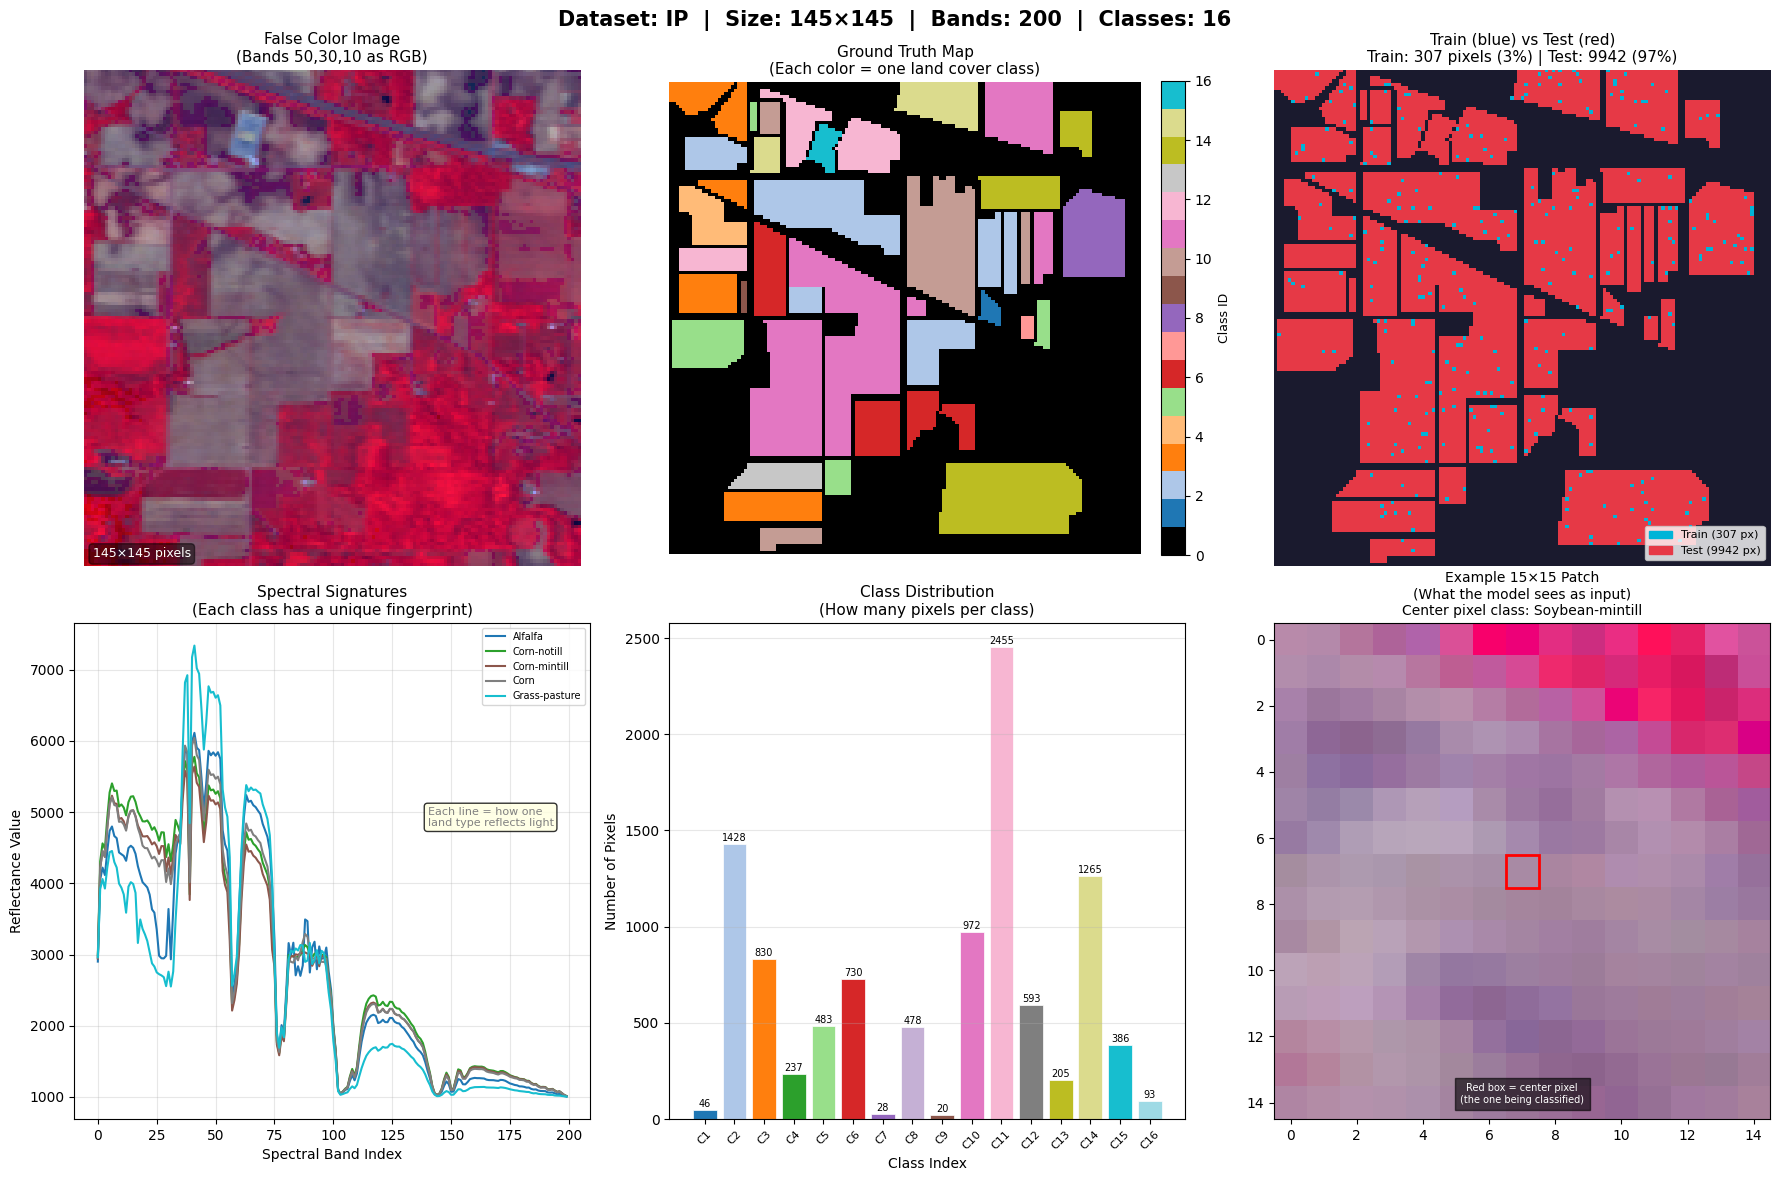

Saved: dataset_visualization_IP.png

STEP 2: Training and evaluating...

  DATASET: IP  |  Device: cuda

  What we are training on:
  - Input to model   : 15x15 patch with 200 spectral bands
  - Features learned : spectral fingerprints + spatial patterns
  - Output           : 1 of 16 land cover classes
  - Training pixels  : 307 (3% of labeled data)
  - Testing  pixels  : 9942 (97% of labeled data)

  Training started...

  Epoch [ 50/300]  Loss: 0.2551  OA: 91.69%
    --> Best model saved! OA: 91.69%
  Epoch [100/300]  Loss: 0.0987  OA: 93.83%
    --> Best model saved! OA: 93.83%
  Epoch [150/300]  Loss: 0.0637  OA: 93.87%
    --> Best model saved! OA: 93.87%
  Epoch [200/300]  Loss: 0.0474  OA: 93.87%
  Epoch [250/300]  Loss: 0.0450  OA: 94.28%
    --> Best model saved! OA: 94.28%
  Epoch [300/300]  Loss: 0.0421  OA: 94.23%

  TEST RESULTS [IP]
  OA    : 94.28%  (Paper: 96.26%)
  AA    : 84.32%  (Paper: 95.69%)
  Kappa : 93.47  (Paper: 95.55)


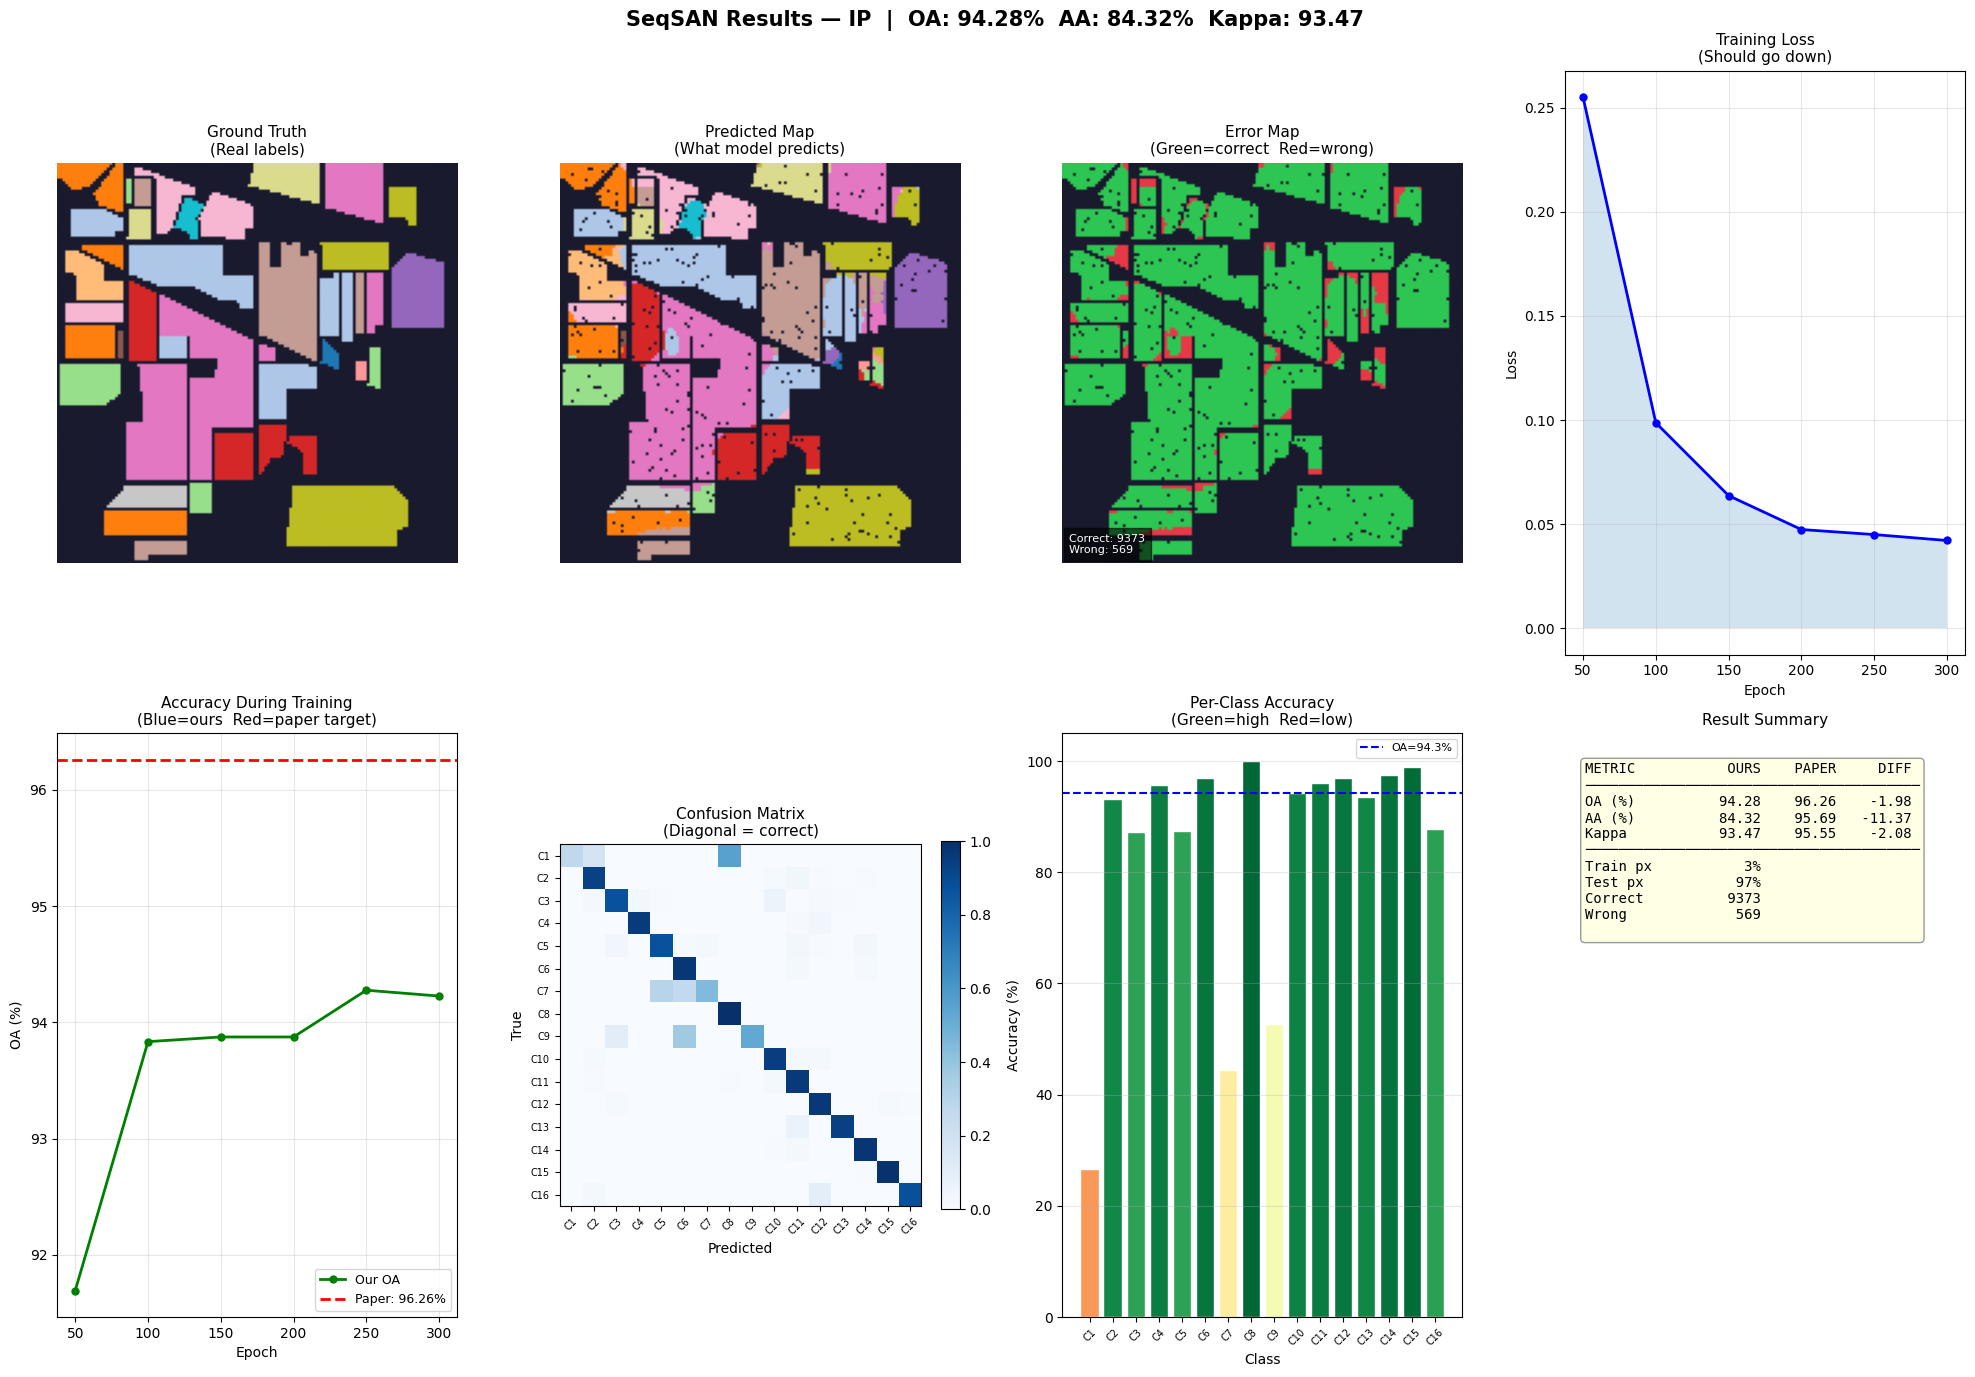

Saved: results_IP.png

STEP 3: Testing on individual pixels...

  Predicting pixel at row=50, col=60
  Predicted class : [2] Corn-notill
  True class      : [0] Unknown/Background
  Correct?        : NO ✗

  Confidence scores (top 5):
  1. Corn-notill                          97.32%  █████████████████████████████
  2. Soybean-clean                         0.40%  
  3. Stone-Steel-Towers                    0.31%  
  4. Grass-pasture                         0.28%  
  5. Woods                                 0.24%  


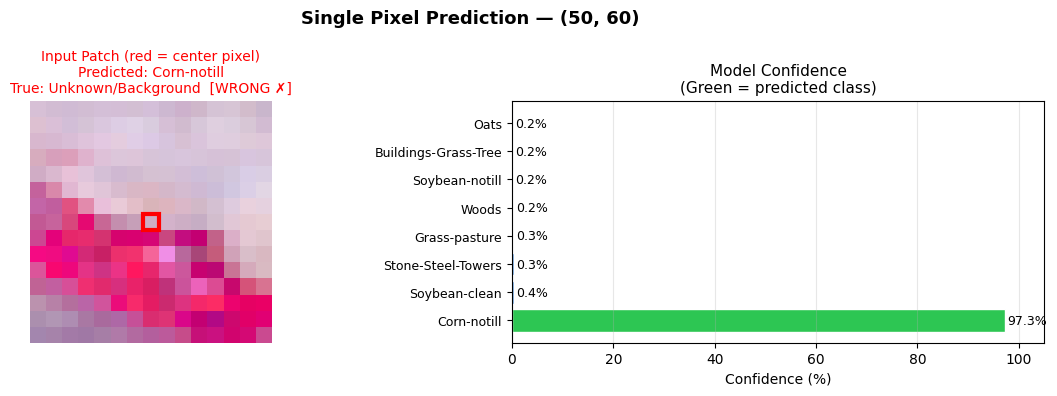


  Predicting pixel at row=80, col=40
  Predicted class : [11] Soybean-mintill
  True class      : [11] Soybean-mintill
  Correct?        : YES ✓

  Confidence scores (top 5):
  1. Soybean-mintill                      97.55%  █████████████████████████████
  2. Grass-trees                           0.33%  
  3. Corn                                  0.22%  
  4. Wheat                                 0.21%  
  5. Buildings-Grass-Trees                 0.19%  


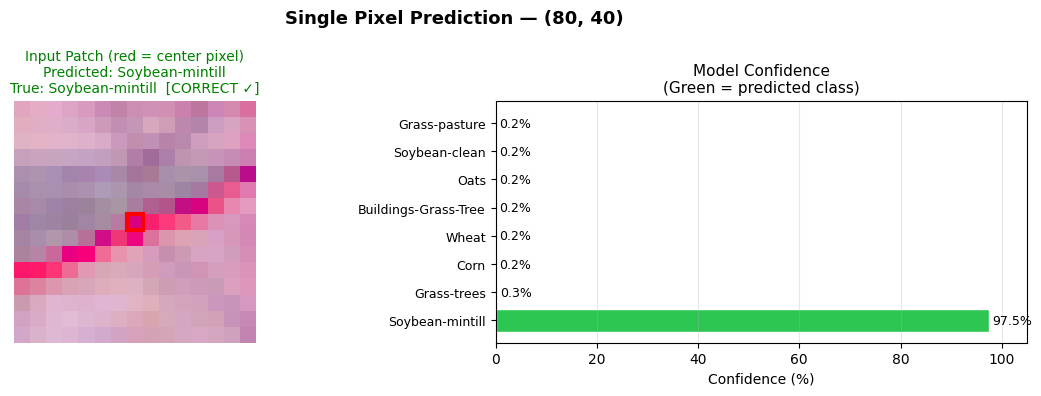


  Predicting pixel at row=100, col=100
  Predicted class : [14] Woods
  True class      : [0] Unknown/Background
  Correct?        : NO ✗

  Confidence scores (top 5):
  1. Woods                                97.24%  █████████████████████████████
  2. Grass-pasture-mowed                   0.31%  
  3. Alfalfa                               0.26%  
  4. Oats                                  0.25%  
  5. Corn-notill                           0.25%  


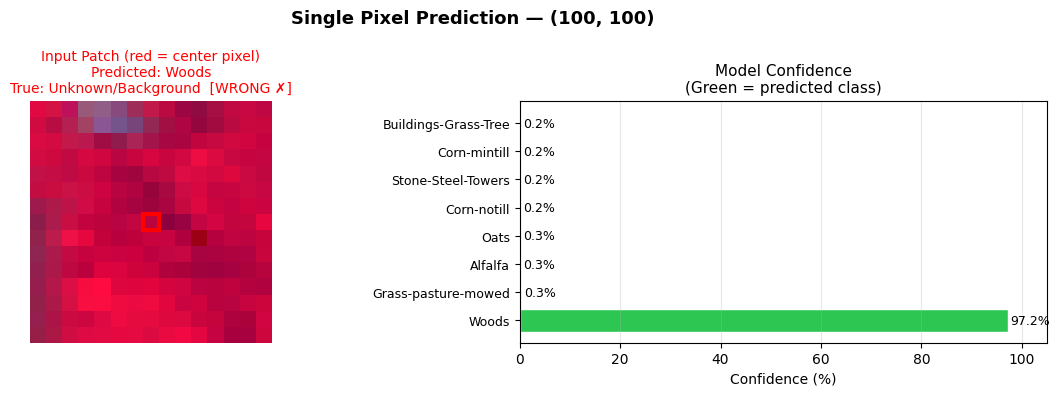

In [9]:
# ============================================================
# SeqSAN - COMPLETE BEGINNER FRIENDLY CODE
# With Dataset Visualization + Training + Testing + Custom Input
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import scipy.io as sio
import urllib.request
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import cohen_kappa_score, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("All imports done!")

# Create a folder for results if it doesn't exist
os.makedirs('saved_results', exist_ok=True)

# ============================================================
# STEP 1: DOWNLOAD DATASET
# ============================================================

os.makedirs('data', exist_ok=True)

def download_datasets():
    files = {
        'Indian_pines_corrected.mat': 'http://www.ehu.eus/ccwintco/uploads/6/67/Indian_pines_corrected.mat',
        'Indian_pines_gt.mat'       : 'http://www.ehu.eus/ccwintco/uploads/c/c4/Indian_pines_gt.mat',
        'Salinas_corrected.mat'     : 'http://www.ehu.eus/ccwintco/uploads/a/a3/Salinas_corrected.mat',
        'Salinas_gt.mat'            : 'http://www.ehu.eus/ccwintco/uploads/f/fa/Salinas_gt.mat',
        'PaviaU.mat'                : 'http://www.ehu.eus/ccwintco/uploads/e/ee/PaviaU.mat',
        'PaviaU_gt.mat'             : 'http://www.ehu.eus/ccwintco/uploads/5/50/PaviaU_gt.mat',
    }
    for fname, url in files.items():
        path = f'data/{fname}'
        if not os.path.exists(path):
            print(f"Downloading {fname}...")
            urllib.request.urlretrieve(url, path)
            print(f"  Done!")
        else:
            print(f"  {fname} already exists.")

download_datasets()

# ============================================================
# STEP 2: DATASET CLASS NAMES (for display)
# ============================================================

CLASS_NAMES = {
    'IP': [
        'Alfalfa', 'Corn-notill', 'Corn-mintill', 'Corn',
        'Grass-pasture', 'Grass-trees', 'Grass-pasture-mowed',
        'Hay-windrowed', 'Oats', 'Soybean-notill', 'Soybean-mintill',
        'Soybean-clean', 'Wheat', 'Woods',
        'Buildings-Grass-Trees', 'Stone-Steel-Towers'
    ],
    'SA': [
        'Broccoli_green_weeds_1', 'Broccoli_green_weeds_2', 'Fallow',
        'Fallow_rough_plow', 'Fallow_smooth', 'Stubble', 'Celery',
        'Grapes_untrained', 'Soil_vinyard_develop',
        'Corn_senesced_green_weeds', 'Lettuce_romaine_4wk',
        'Lettuce_romaine_5wk', 'Lettuce_romaine_6wk',
        'Lettuce_romaine_7wk', 'Vinyard_untrained',
        'Vinyard_vertical_trellis'
    ],
    'PU': [
        'Asphalt', 'Meadows', 'Gravel', 'Trees',
        'Painted metal sheets', 'Bare Soil', 'Bitumen',
        'Self-Blocking Bricks', 'Shadows'
    ],
}

# ============================================================
# STEP 3: DATASET VISUALIZATION
# (Show what the dataset looks like BEFORE training)
# ============================================================

def visualize_dataset(name):
    """
    Show 4 things:
    1. False color image (like a photo of the scene)
    2. Ground truth map (what each pixel really is)
    3. Spectral signature (the fingerprint of each class)
    4. Class distribution (how many pixels per class)
    """
    print(f"\nVisualizing {name} dataset...")

    data, labels = load_dataset(name)
    H, W, B      = data.shape
    num_classes  = int(labels.max())
    class_names  = CLASS_NAMES.get(name, [f'Class {i}' for i in range(1, num_classes+1)])

    fig = plt.figure(figsize=(18, 12))
    fig.suptitle(f'Dataset: {name}  |  Size: {H}×{W}  |  Bands: {B}  |  Classes: {num_classes}',
                 fontsize=15, fontweight='bold')

    # --- Plot 1: False Color Image ---
    # Pick 3 bands to display as RGB (like a fake photo)
    ax1 = fig.add_subplot(2, 3, 1)
    r_band = min(50, B-1)
    g_band = min(30, B-1)
    b_band = min(10, B-1)
    rgb = data[:, :, [r_band, g_band, b_band]]
    # Normalize to 0-1 for display
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())
    ax1.imshow(rgb)
    ax1.set_title(f'False Color Image\n(Bands {r_band},{g_band},{b_band} as RGB)',
                  fontsize=11)
    ax1.axis('off')
    ax1.text(2, H-3, f'{H}×{W} pixels', color='white', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))

    # --- Plot 2: Ground Truth Map ---
    ax2 = fig.add_subplot(2, 3, 2)
    # Create colormap
    colors_list = plt.cm.tab20(np.linspace(0, 1, num_classes + 1))
    cmap        = ListedColormap(['black'] + list(colors_list[:num_classes]))
    im          = ax2.imshow(labels, cmap=cmap,
                              vmin=0, vmax=num_classes)
    ax2.set_title('Ground Truth Map\n(Each color = one land cover class)',
                  fontsize=11)
    ax2.axis('off')
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
    cbar.set_label('Class ID', fontsize=9)

    # --- Plot 3: What 3% training vs 97% test looks like ---
    ax3 = fig.add_subplot(2, 3, 3)
    labeled_mask = (labels > 0).astype(int)
    # Simulate 3% split
    labeled_pixels = np.argwhere(labels > 0)
    n_train        = int(len(labeled_pixels) * 0.03)
    np.random.seed(42)
    train_idx   = np.random.choice(len(labeled_pixels), n_train, replace=False)
    train_map   = np.zeros_like(labels)
    test_map    = np.zeros_like(labels)
    for idx in range(len(labeled_pixels)):
        r, c = labeled_pixels[idx]
        if idx in train_idx:
            train_map[r, c] = 1   # training pixel
        elif labels[r, c] > 0:
            test_map[r, c]  = 2   # test pixel

    split_vis = train_map + test_map
    split_cmap = ListedColormap(['#1a1a2e', '#00b4d8', '#e63946'])
    ax3.imshow(split_vis, cmap=split_cmap)
    ax3.set_title(f'Train (blue) vs Test (red)\n'
                  f'Train: {n_train} pixels (3%) | Test: {len(labeled_pixels)-n_train} (97%)',
                  fontsize=11)
    ax3.axis('off')
    patches_legend = [
        mpatches.Patch(color='#00b4d8', label=f'Train ({n_train} px)'),
        mpatches.Patch(color='#e63946', label=f'Test ({len(labeled_pixels)-n_train} px)'),
    ]
    ax3.legend(handles=patches_legend, loc='lower right', fontsize=8)

    # --- Plot 4: Spectral Signatures ---
    ax4 = fig.add_subplot(2, 3, 4)
    colors_sig = plt.cm.tab10(np.linspace(0, 1, min(5, num_classes)))
    for c_idx in range(min(5, num_classes)):
        class_id   = c_idx + 1
        mask       = (labels == class_id)
        if mask.sum() > 0:
            # Average spectrum for this class
            pixels    = data[mask]
            mean_spec = pixels.mean(axis=0)
            ax4.plot(range(B), mean_spec,
                     color=colors_sig[c_idx], linewidth=1.5,
                     label=class_names[c_idx][:20] if c_idx < len(class_names) else f'C{class_id}')
    ax4.set_xlabel('Spectral Band Index')
    ax4.set_ylabel('Reflectance Value')
    ax4.set_title('Spectral Signatures\n(Each class has a unique fingerprint)',
                  fontsize=11)
    ax4.legend(fontsize=7, loc='upper right')
    ax4.grid(True, alpha=0.3)

    # Add annotation explaining spectral signature
    ax4.annotate('Each line = how one\nland type reflects light',
                 xy=(B*0.7, data.max()*0.5),
                 fontsize=8, color='gray',
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    # --- Plot 5: Class Distribution ---
    ax5 = fig.add_subplot(2, 3, 5)
    class_counts = []
    for c in range(1, num_classes + 1):
        class_counts.append((labels == c).sum())

    bars = ax5.bar(range(num_classes), class_counts,
                   color=plt.cm.tab20(np.linspace(0, 1, num_classes)),
                   edgecolor='white', linewidth=0.5)
    ax5.set_xlabel('Class Index')
    ax5.set_ylabel('Number of Pixels')
    ax5.set_title('Class Distribution\n(How many pixels per class)',
                  fontsize=11)
    ax5.set_xticks(range(num_classes))
    ax5.set_xticklabels([f'C{i+1}' for i in range(num_classes)],
                         rotation=45, fontsize=8)
    ax5.grid(True, axis='y', alpha=0.3)
    # Label the bars
    for bar, count in zip(bars, class_counts):
        ax5.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                 str(count), ha='center', va='bottom', fontsize=7)

    # --- Plot 6: What a patch looks like ---
    ax6 = fig.add_subplot(2, 3, 6)
    # Find first labeled pixel
    r0, c0    = labeled_pixels[len(labeled_pixels)//2]
    pad       = 7
    r0c       = np.clip(r0, pad, H-pad-1)
    c0c       = np.clip(c0, pad, W-pad-1)
    patch_rgb = data[r0c-pad:r0c+pad+1, c0c-pad:c0c+pad+1, [r_band,g_band,b_band]]
    patch_rgb = (patch_rgb - patch_rgb.min()) / (patch_rgb.max() - patch_rgb.min() + 1e-8)
    ax6.imshow(patch_rgb)
    ax6.set_title(f'Example 15×15 Patch\n(What the model sees as input)\n'
                  f'Center pixel class: {class_names[labels[r0c,c0c]-1][:25] if labels[r0c,c0c]>0 else "Unknown"}',
                  fontsize=10)
    # Draw center pixel highlight
    rect = plt.Rectangle((6.5, 6.5), 1, 1,
                          linewidth=2, edgecolor='red', facecolor='none')
    ax6.add_patch(rect)
    ax6.text(7, 14, 'Red box = center pixel\n(the one being classified)',
             ha='center', color='white', fontsize=7,
             bbox=dict(facecolor='black', alpha=0.6))

    plt.tight_layout()
    plt.savefig(f'dataset_visualization_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: dataset_visualization_{name}.png")

# ============================================================
# STEP 4: DATA FUNCTIONS
# ============================================================

def load_dataset(name):
    if name == 'IP':
        data   = sio.loadmat('data/Indian_pines_corrected.mat')['indian_pines_corrected']
        labels = sio.loadmat('data/Indian_pines_gt.mat')['indian_pines_gt']
    elif name == 'SA':
        data   = sio.loadmat('data/Salinas_corrected.mat')['salinas_corrected']
        labels = sio.loadmat('data/Salinas_gt.mat')['salinas_gt']
    elif name == 'PU':
        data   = sio.loadmat('data/PaviaU.mat')['paviaU']
        labels = sio.loadmat('data/PaviaU_gt.mat')['paviaU_gt']
    return data.astype(np.float32), labels

def normalize_data(data):
    H, W, B = data.shape
    flat    = data.reshape(-1, B)
    scaler  = StandardScaler()
    flat    = scaler.fit_transform(flat)
    return flat.reshape(H, W, B).astype(np.float32), scaler

def create_patches(data, labels, patch_size=15):
    H, W, B = data.shape
    pad     = patch_size // 2
    padded  = np.pad(data, ((pad,pad),(pad,pad),(0,0)), mode='reflect')
    patches, targets, coords = [], [], []
    for i in range(H):
        for j in range(W):
            if labels[i, j] > 0:
                patch = padded[i:i+patch_size, j:j+patch_size, :]
                patches.append(patch)
                targets.append(int(labels[i, j]) - 1)
                coords.append((i, j))
    return (np.array(patches, dtype=np.float32),
            np.array(targets, dtype=np.int64),
            coords)

def split_train_test(patches, targets, coords, train_ratio=0.03, seed=42):
    idx      = np.arange(len(patches))
    tr_idx, te_idx = train_test_split(
        idx, train_size=train_ratio,
        random_state=seed, stratify=targets)
    return (patches[tr_idx], patches[te_idx],
            targets[tr_idx], targets[te_idx],
            [coords[i] for i in tr_idx],
            [coords[i] for i in te_idx])

# ============================================================
# STEP 5: MODEL
# ============================================================

class S3Module(nn.Module):
    def __init__(self, channels, hidden_dim=32):
        super().__init__()
        self.lstm_w = nn.LSTM(channels, hidden_dim, batch_first=True, bidirectional=True)
        self.lstm_h = nn.LSTM(channels, hidden_dim, batch_first=True, bidirectional=True)
        self.lstm_c = nn.LSTM(channels, hidden_dim, batch_first=True, bidirectional=True)
        self.proj   = nn.Linear(hidden_dim * 2, channels)

    def forward(self, x):
        B, H, W, C = x.shape
        xW = x.permute(0,2,1,3).reshape(B*W, H, C)
        xW, _ = self.lstm_w(xW)
        xW = self.proj(xW).reshape(B,W,H,-1).permute(0,2,1,3)
        xH = x.reshape(B*H, W, C)
        xH, _ = self.lstm_h(xH)
        xH = self.proj(xH).reshape(B,H,W,-1)
        xC = x.reshape(B, H*W, C)
        xC, _ = self.lstm_c(xC)
        xC = self.proj(xC).reshape(B,H,W,-1)
        return xW, xH, xC

class TSAModule(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm  = nn.LayerNorm(channels)
        self.scale = channels ** -0.5

    def forward(self, xW, xH, xC):
        B, H, W, C = xW.shape
        Q    = xW.reshape(B, H*W, C)
        K    = xH.reshape(B, H*W, C)
        V    = xC.reshape(B, H*W, C)
        attn = torch.softmax(torch.bmm(Q, K.transpose(1,2)) * self.scale, dim=-1)
        out  = torch.bmm(attn, V)
        return self.norm(out).reshape(B, H, W, C)

class SeqSANBlock(nn.Module):
    def __init__(self, channels, hidden_dim=32):
        super().__init__()
        self.s3    = S3Module(channels, hidden_dim)
        self.tsa   = TSAModule(channels)
        self.mlp   = nn.Sequential(
            nn.Linear(channels, channels*2), nn.GELU(),
            nn.Linear(channels*2, channels))
        self.norm1 = nn.LayerNorm(channels)
        self.norm2 = nn.LayerNorm(channels)

    def forward(self, x):
        res         = x
        xW,xH,xC   = self.s3(self.norm1(x))
        x           = res + self.tsa(xW, xH, xC)
        x           = x + self.mlp(self.norm2(x))
        return x

class SeqSAN(nn.Module):
    def __init__(self, in_bands, num_classes, channels=64, depth=3, hidden_dim=32):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_bands, channels, 3, padding=1),
            nn.BatchNorm2d(channels), nn.GELU())
        self.blocks = nn.ModuleList([SeqSANBlock(channels, hidden_dim) for _ in range(depth)])
        self.pools  = nn.ModuleList(
            [nn.AvgPool2d(2) if i < depth-1 else nn.Identity() for i in range(depth)])
        self.head   = nn.Sequential(nn.LayerNorm(channels), nn.Linear(channels, num_classes))

    def forward(self, x):
        x = self.stem(x.permute(0,3,1,2)).permute(0,2,3,1)
        for blk, pool in zip(self.blocks, self.pools):
            x = blk(x)
            if not isinstance(pool, nn.Identity):
                x = pool(x.permute(0,3,1,2)).permute(0,2,3,1)
        return self.head(x.mean(dim=(1,2)))

# ============================================================
# STEP 6: TRAIN + TEST + VISUALIZE RESULTS
# ============================================================

PAPER_RESULTS = {
    'IP': {'OA': 96.26, 'AA': 95.69, 'Kappa': 95.55},
    'SA': {'OA': 99.76, 'AA': 99.87, 'Kappa': 99.83},
    'PU': {'OA': 99.31, 'AA': 99.22, 'Kappa': 99.48},
}

def train_and_evaluate(dataset_name='IP', epochs=300,
                        batch_size=64, lr=1e-4, seed=42):

    torch.manual_seed(seed)
    np.random.seed(seed)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    print(f"\n{'='*55}")
    print(f"  DATASET: {dataset_name}  |  Device: {device}")
    print(f"{'='*55}")

    # --- Load ---
    data, labels     = load_dataset(dataset_name)
    data_norm, scaler = normalize_data(data)
    patches, targets, coords = create_patches(data_norm, labels)

    X_tr, X_te, y_tr, y_te, c_tr, c_te = split_train_test(
        patches, targets, coords, 0.03, seed)

    in_bands    = patches.shape[-1]
    num_classes = len(np.unique(targets))
    class_names = CLASS_NAMES.get(dataset_name,
                  [f'Class {i+1}' for i in range(num_classes)])

    print(f"\n  What we are training on:")
    print(f"  - Input to model   : 15x15 patch with {in_bands} spectral bands")
    print(f"  - Features learned : spectral fingerprints + spatial patterns")
    print(f"  - Output           : 1 of {num_classes} land cover classes")
    print(f"  - Training pixels  : {len(X_tr)} (3% of labeled data)")
    print(f"  - Testing  pixels  : {len(X_te)} (97% of labeled data)")

    # --- Loaders ---
    tr_loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_tr), torch.LongTensor(y_tr)),
        batch_size=batch_size, shuffle=True, num_workers=0)
    te_loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_te), torch.LongTensor(y_te)),
        batch_size=batch_size, shuffle=False, num_workers=0)

    # --- Model ---
    model     = SeqSAN(in_bands, num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)
    criterion = nn.CrossEntropyLoss()

    history   = {'epoch':[], 'loss':[], 'oa':[]}
    best_oa   = 0

    print(f"\n  Training started...\n")

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for Xb, yb in tr_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()

        if (epoch+1) % 50 == 0:
            model.eval()
            correct, total = 0, 0
            with torch.no_grad():
                for Xb, yb in te_loader:
                    pred     = model(Xb.to(device)).argmax(1)
                    correct += (pred == yb.to(device)).sum().item()
                    total   += len(yb)
            oa  = correct / total * 100
            avg = total_loss / len(tr_loader)
            history['epoch'].append(epoch+1)
            history['loss'].append(avg)
            history['oa'].append(oa)
            print(f"  Epoch [{epoch+1:>3}/{epochs}]  "
                  f"Loss: {avg:.4f}  OA: {oa:.2f}%")
            if oa > best_oa:
                best_oa = oa
                torch.save(model.state_dict(),
                           f'seqsan_{dataset_name}_best.pth')
                print(f"    --> Best model saved! OA: {best_oa:.2f}%")

    # --- Final Test ---
    model.load_state_dict(
        torch.load(f'seqsan_{dataset_name}_best.pth', map_location=device))
    model.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for Xb, yb in te_loader:
            pred = model(Xb.to(device)).argmax(1).cpu().numpy()
            all_preds.extend(pred)
            all_labels.extend(yb.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    OA    = accuracy_score(all_labels, all_preds) * 100
    AA    = np.mean([accuracy_score(all_labels[all_labels==c],
                                    all_preds[all_labels==c])
                     for c in range(num_classes)
                     if (all_labels==c).sum() > 0]) * 100
    Kappa = cohen_kappa_score(all_labels, all_preds) * 100
    CM    = confusion_matrix(all_labels, all_preds)

    print(f"\n  TEST RESULTS [{dataset_name}]")
    print(f"  OA    : {OA:.2f}%  (Paper: {PAPER_RESULTS.get(dataset_name,{}).get('OA',0):.2f}%)")
    print(f"  AA    : {AA:.2f}%  (Paper: {PAPER_RESULTS.get(dataset_name,{}).get('AA',0):.2f}%)")
    print(f"  Kappa : {Kappa:.2f}  (Paper: {PAPER_RESULTS.get(dataset_name,{}).get('Kappa',0):.2f})")

    # ---- VISUALIZE RESULTS ----
    visualize_results(
        dataset_name, data, labels, all_preds, all_labels,
        c_te, CM, history, num_classes, class_names,
        OA, AA, Kappa, model, device, scaler, in_bands)

    return {
        'dataset': dataset_name, 'OA': OA, 'AA': AA, 'Kappa': Kappa,
        'CM': CM, 'history': history, 'num_classes': num_classes,
        'model': model, 'scaler': scaler, 'in_bands': in_bands,
        'class_names': class_names, 'data': data, 'labels': labels,
    }

# ============================================================
# STEP 7: RESULTS VISUALIZATION
# ============================================================

def visualize_results(name, data, labels, preds, true_labels,
                      test_coords, CM, history, num_classes,
                      class_names, OA, AA, Kappa, model,
                      device, scaler, in_bands):

    H, W, B = data.shape

    fig = plt.figure(figsize=(20, 14))
    fig.suptitle(f'SeqSAN Results — {name}  |  OA: {OA:.2f}%  AA: {AA:.2f}%  Kappa: {Kappa:.2f}',
                 fontsize=15, fontweight='bold')

    # --- 1. Ground Truth Map ---
    ax1 = fig.add_subplot(2, 4, 1)
    cmap = ListedColormap(
        ['#1a1a2e'] + [plt.cm.tab20(i/num_classes) for i in range(num_classes)])
    ax1.imshow(labels, cmap=cmap, vmin=0, vmax=num_classes)
    ax1.set_title('Ground Truth\n(Real labels)', fontsize=11)
    ax1.axis('off')

    # --- 2. Predicted Map ---
    ax2 = fig.add_subplot(2, 4, 2)
    pred_map = np.zeros_like(labels)
    for idx, (r, c) in enumerate(test_coords):
        pred_map[r, c] = preds[idx] + 1
    ax2.imshow(pred_map, cmap=cmap, vmin=0, vmax=num_classes)
    ax2.set_title('Predicted Map\n(What model predicts)', fontsize=11)
    ax2.axis('off')

    # --- 3. Error Map ---
    ax3 = fig.add_subplot(2, 4, 3)
    error_map = np.zeros((H, W), dtype=np.float32)
    for idx, (r, c) in enumerate(test_coords):
        error_map[r, c] = 1 if preds[idx] != true_labels[idx] else 2
    cmap_err = ListedColormap(['#1a1a2e', '#e63946', '#2dc653'])
    ax3.imshow(error_map, cmap=cmap_err, vmin=0, vmax=2)
    ax3.set_title('Error Map\n(Green=correct  Red=wrong)', fontsize=11)
    ax3.axis('off')
    n_wrong  = (preds != true_labels).sum()
    n_right  = (preds == true_labels).sum()
    ax3.text(2, H-4, f'Correct: {n_right}\nWrong: {n_wrong}',
             color='white', fontsize=8,
             bbox=dict(facecolor='black', alpha=0.6))

    # --- 4. Training Loss ---
    ax4 = fig.add_subplot(2, 4, 4)
    ax4.plot(history['epoch'], history['loss'],
             'b-o', linewidth=2, markersize=5)
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Loss')
    ax4.set_title('Training Loss\n(Should go down)', fontsize=11)
    ax4.grid(True, alpha=0.3)
    ax4.fill_between(history['epoch'], history['loss'], alpha=0.2)

    # --- 5. OA Curve ---
    ax5 = fig.add_subplot(2, 4, 5)
    ax5.plot(history['epoch'], history['oa'],
             'g-o', linewidth=2, markersize=5, label='Our OA')
    paper_oa = PAPER_RESULTS.get(name, {}).get('OA', 0)
    if paper_oa:
        ax5.axhline(y=paper_oa, color='r', linestyle='--',
                    linewidth=2, label=f'Paper: {paper_oa}%')
    ax5.set_xlabel('Epoch')
    ax5.set_ylabel('OA (%)')
    ax5.set_title('Accuracy During Training\n(Blue=ours  Red=paper target)', fontsize=11)
    ax5.legend(fontsize=9)
    ax5.grid(True, alpha=0.3)

    # --- 6. Confusion Matrix ---
    ax6 = fig.add_subplot(2, 4, 6)
    CM_norm = CM.astype(float)
    for i in range(len(CM_norm)):
        s = CM_norm[i].sum()
        if s > 0:
            CM_norm[i] /= s
    im = ax6.imshow(CM_norm, cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax6, fraction=0.046)
    ax6.set_title('Confusion Matrix\n(Diagonal = correct)', fontsize=11)
    ax6.set_xlabel('Predicted')
    ax6.set_ylabel('True')
    ax6.set_xticks(range(num_classes))
    ax6.set_yticks(range(num_classes))
    ax6.set_xticklabels([f'C{i+1}' for i in range(num_classes)],
                         rotation=45, fontsize=7)
    ax6.set_yticklabels([f'C{i+1}' for i in range(num_classes)], fontsize=7)

    # --- 7. Per-class accuracy bar ---
    ax7 = fig.add_subplot(2, 4, 7)
    per_class_acc = []
    for c in range(num_classes):
        mask = (true_labels == c)
        if mask.sum() > 0:
            acc = (preds[mask] == true_labels[mask]).mean() * 100
        else:
            acc = 0
        per_class_acc.append(acc)

    bars = ax7.bar(range(num_classes), per_class_acc,
                   color=[plt.cm.RdYlGn(v/100) for v in per_class_acc],
                   edgecolor='white')
    ax7.axhline(y=OA, color='blue', linestyle='--',
                linewidth=1.5, label=f'OA={OA:.1f}%')
    ax7.set_xlabel('Class')
    ax7.set_ylabel('Accuracy (%)')
    ax7.set_title('Per-Class Accuracy\n(Green=high  Red=low)', fontsize=11)
    ax7.set_xticks(range(num_classes))
    ax7.set_xticklabels([f'C{i+1}' for i in range(num_classes)],
                         rotation=45, fontsize=7)
    ax7.set_ylim(0, 105)
    ax7.legend(fontsize=8)
    ax7.grid(True, axis='y', alpha=0.3)

    # --- 8. Summary scorecard ---
    ax8 = fig.add_subplot(2, 4, 8)
    ax8.axis('off')
    paper = PAPER_RESULTS.get(name, {})
    summary_text = (
        f"{'METRIC':<12} {'OURS':>8} {'PAPER':>8} {'DIFF':>8}\n"
        f"{'─'*40}\n"
        f"{'OA (%)' :<12} {OA:>8.2f} {paper.get('OA',0):>8.2f} "
        f"{OA-paper.get('OA',0):>+8.2f}\n"
        f"{'AA (%)' :<12} {AA:>8.2f} {paper.get('AA',0):>8.2f} "
        f"{AA-paper.get('AA',0):>+8.2f}\n"
        f"{'Kappa'  :<12} {Kappa:>8.2f} {paper.get('Kappa',0):>8.2f} "
        f"{Kappa-paper.get('Kappa',0):>+8.2f}\n"
        f"{'─'*40}\n"
        f"{'Train px':<12} {'3%':>8}\n"
        f"{'Test px' :<12} {'97%':>8}\n"
        f"{'Correct' :<12} {n_right:>8}\n"
        f"{'Wrong'   :<12} {n_wrong:>8}\n"
    )
    ax8.text(0.05, 0.95, summary_text,
             transform=ax8.transAxes,
             fontsize=10, verticalalignment='top',
             fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightyellow',
                       alpha=0.8, edgecolor='gray'))
    ax8.set_title('Result Summary', fontsize=11)

    plt.tight_layout()
    plt.savefig(f'results_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: results_{name}.png")

# ============================================================
# STEP 8: PREDICT A SINGLE CUSTOM PIXEL
# (Pass any pixel location and see what the model predicts)
# ============================================================

def predict_single_pixel(result, row, col):
    """
    Give any pixel location (row, col) in the image
    and see what the model predicts for it.

    Example:
        predict_single_pixel(result_ip, row=50, col=60)
    """
    model       = result['model']
    scaler      = result['scaler']
    data        = result['data']
    labels      = result['labels']
    class_names = result['class_names']
    device      = 'cuda' if torch.cuda.is_available() else 'cpu'

    H, W, B     = data.shape
    patch_size  = 15
    pad         = patch_size // 2

    # Clamp to valid range
    row = int(np.clip(row, pad, H-pad-1))
    col = int(np.clip(col, pad, W-pad-1))

    # Normalize using same scaler as training
    data_flat  = data.reshape(-1, B)
    data_norm  = scaler.transform(data_flat).reshape(H, W, B).astype(np.float32)

    # Extract patch
    padded = np.pad(data_norm, ((pad,pad),(pad,pad),(0,0)), mode='reflect')
    patch  = padded[row:row+patch_size, col:col+patch_size, :]
    patch_tensor = torch.FloatTensor(patch).unsqueeze(0).to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        logits = model(patch_tensor)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred   = probs.argmax()

    true_label = int(labels[row, col])
    pred_name  = class_names[pred] if pred < len(class_names) else f'Class {pred+1}'
    true_name  = class_names[true_label-1] if (0 < true_label <= len(class_names)) else 'Unknown/Background'

    print(f"\n{'='*50}")
    print(f"  Predicting pixel at row={row}, col={col}")
    print(f"{'='*50}")
    print(f"  Predicted class : [{pred+1}] {pred_name}")
    print(f"  True class      : [{true_label}] {true_name}")
    print(f"  Correct?        : {'YES ✓' if pred+1==true_label else 'NO ✗'}")
    print(f"\n  Confidence scores (top 5):")

    top5_idx  = probs.argsort()[::-1][:5]
    for rank, idx in enumerate(top5_idx):
        cname = class_names[idx] if idx < len(class_names) else f'Class {idx+1}'
        bar   = '█' * int(probs[idx] * 30)
        print(f"  {rank+1}. {cname:<35} {probs[idx]*100:>6.2f}%  {bar}")

    # Plot the patch + bar chart
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Single Pixel Prediction — ({row}, {col})',
                 fontsize=13, fontweight='bold')

    # Show the patch
    r_band = min(50, B-1)
    g_band = min(30, B-1)
    b_band = min(10, B-1)
    patch_rgb = data[row-pad:row+pad+1, col-pad:col+pad+1, [r_band,g_band,b_band]]
    patch_rgb = (patch_rgb - patch_rgb.min()) / (patch_rgb.max()-patch_rgb.min()+1e-8)
    ax1.imshow(patch_rgb)
    rect = plt.Rectangle((pad-0.5, pad-0.5), 1, 1,
                          linewidth=3, edgecolor='red', facecolor='none')
    ax1.add_patch(rect)
    color   = 'green' if pred+1 == true_label else 'red'
    verdict = 'CORRECT ✓' if pred+1 == true_label else 'WRONG ✗'
    ax1.set_title(f'Input Patch (red = center pixel)\n'
                  f'Predicted: {pred_name[:30]}\n'
                  f'True: {true_name[:30]}  [{verdict}]',
                  fontsize=10, color=color)
    ax1.axis('off')

    # Show confidence bar chart
    top_n   = min(8, len(class_names))
    top_idx = probs.argsort()[::-1][:top_n]
    top_probs = probs[top_idx] * 100
    top_names = [class_names[i][:20] if i < len(class_names)
                 else f'C{i+1}' for i in top_idx]
    bar_colors = ['#2dc653' if i == pred else '#4a90d9' for i in top_idx]
    bars = ax2.barh(range(top_n), top_probs,
                    color=bar_colors, edgecolor='white')
    ax2.set_yticks(range(top_n))
    ax2.set_yticklabels(top_names, fontsize=9)
    ax2.set_xlabel('Confidence (%)')
    ax2.set_title('Model Confidence\n(Green = predicted class)', fontsize=11)
    ax2.set_xlim(0, 105)
    for bar, val in zip(bars, top_probs):
        ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)
    ax2.grid(True, axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'single_pixel_prediction_{row}_{col}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

def plot_comparison_all(all_results):
    datasets = [r['dataset'] for r in all_results]
    metrics  = ['OA', 'AA', 'Kappa']
    colors   = {'Ours': '#2196F3', 'Paper': '#FF5722'}

    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    fig.suptitle('SeqSAN Results vs Paper — All Datasets',
                 fontsize=15, fontweight='bold')

    x      = np.arange(len(datasets))
    width  = 0.35

    for idx, metric in enumerate(metrics):
        ax         = axes[idx]
        our_vals   = [r[metric] for r in all_results]
        paper_vals = [PAPER_RESULTS[r['dataset']][metric]
                      if r['dataset'] in PAPER_RESULTS else 0
                      for r in all_results]

        bars1 = ax.bar(x - width/2, our_vals,   width,
                       label='Our results', color=colors['Ours'],
                       alpha=0.85, edgecolor='white')
        bars2 = ax.bar(x + width/2, paper_vals, width,
                       label='Paper results', color=colors['Paper'],
                       alpha=0.85, edgecolor='white')

        # Value labels on bars
        for bar in bars1:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., h + 0.1,
                    f'{h:.1f}', ha='center', va='bottom', fontsize=9)
        for bar in bars2:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., h + 0.1,
                    f'{h:.1f}', ha='center', va='bottom', fontsize=9)

        ax.set_xlabel('Dataset', fontsize=11)
        ax.set_ylabel(f'{metric} (%)', fontsize=11)
        ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(datasets)
        ax.legend(fontsize=9)
        ax.grid(True, axis='y', alpha=0.3)

        # Set y-axis range
        all_vals = our_vals + paper_vals
        if all_vals:
            ymin = max(0, min(all_vals) - 5)
            ax.set_ylim(ymin, 101)

    plt.tight_layout()
    plt.savefig('comparison_all_datasets.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: comparison_all_datasets.png")

def plot_oa_radar(all_results):
    """Radar/spider plot comparing OA across datasets"""
    datasets   = [r['dataset'] for r in all_results]
    our_vals   = [r['OA'] for r in all_results]
    paper_vals = [PAPER_RESULTS[r['dataset']]['OA']
                  for r in all_results if r['dataset'] in PAPER_RESULTS]

    N      = len(datasets)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    our_vals_plot   = our_vals   + our_vals[:1]
    paper_vals_plot = paper_vals + paper_vals[:1]

    fig, ax = plt.subplots(figsize=(7, 7),
                           subplot_kw=dict(polar=True))
    ax.plot(angles, our_vals_plot,   'b-o', linewidth=2,
            markersize=8, label='Our results')
    ax.fill(angles, our_vals_plot,   alpha=0.15, color='blue')
    ax.plot(angles, paper_vals_plot, 'r--s', linewidth=2,
            markersize=8, label='Paper results')
    ax.fill(angles, paper_vals_plot, alpha=0.1, color='red')

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(datasets, fontsize=13)
    ax.set_ylim(85, 101)
    ax.set_title('OA Comparison — Radar Chart',
                 fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    ax.grid(True)

    plt.tight_layout()
    plt.savefig('radar_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: radar_comparison.png")
# ============================================================
# STEP 9: RUN EVERYTHING
# ============================================================

# --- First: Visualize the dataset BEFORE training ---
print("STEP 1: Visualizing dataset...")
visualize_dataset('IP')

# --- Then: Train + Test ---
print("\nSTEP 2: Training and evaluating...")
result_ip = train_and_evaluate('IP', epochs=300)

# --- Then: Predict a single custom pixel ---
print("\nSTEP 3: Testing on individual pixels...")

# Try pixel at row=50, col=60
predict_single_pixel(result_ip, row=50, col=60)

# Try another pixel
predict_single_pixel(result_ip, row=80, col=40)

# Try any pixel you want:
predict_single_pixel(result_ip, row=100, col=100)